# 🧬 Entrenamiento con Colas Enriquecidas (KNN Imputation) y Evaluación Final

## 🎯 Objetivo del Cuaderno
Este *notebook* corona la fase de experimentación del proyecto al evaluar el rendimiento de los modelos sobre el **dataset enriquecido estratégicamente en las colas**. Tras detectar que el error predictivo se disparaba en los inmuebles atípicamente baratos o caros, se inyectaron datos reales del portal Redpiso en esos segmentos, imputando sus variables de IA faltantes mediante *K-Nearest Neighbors* para mantener la varianza y la coherencia del mercado local.

El objetivo es cuantificar si este "parche" de datos altamente específicos logra reducir el MAE (Error Medio Absoluto) en los deciles extremos de la distribución de precios, comparándolo con el rendimiento del *Champion Model* original.

## ⚙️ Metodología y Flujo de Entrenamiento

### 1. Carga de Datos y Ajuste del Target
Se carga el dataset `tecnocasa_colas_knn.parquet`, que contiene la base original de Tecnocasa fusionada con las colas imputadas de Redpiso. 
Como en arquitecturas anteriores, para combatir la asimetría de los precios y evitar predicciones irracionales, la variable objetivo a predecir no es el precio bruto, sino el **logaritmo del Precio por metro cuadrado**.

### 2. Partición Estratificada (*Train/Test Split*)
Para asegurar que el conjunto de evaluación (*Test Set*) contenga una muestra verdaderamente representativa de las nuevas colas inyectadas, la partición se realiza dividiendo el *target* original en 20 contenedores (o *bins*) y realizando un muestreo estratificado proporcional al 20%.

### 3. Pipeline de Machine Learning
El flujo de transformación se mantiene estandarizado para permitir una comparación justa con los experimentos previos:
* **Preprocesamiento:** Imputación de nulos (`SimpleImputer`) y codificación paramétrica (`OneHotEncoder`). Para los modelos sensibles a la escala (como Ridge o las Redes Neuronales), se acopla un `StandardScaler`.
* **Optimización Bayesiana (Optuna):** Se barren espacios de hiperparámetros complejos en 7 arquitecturas algorítmicas (XGBoost, Random Forest, GBR, Ridge, Lasso, ElasticNet y Keras/TensorFlow) maximizando el rendimiento sobre una validación cruzada (*KFold*) de 5 divisiones.

### 4. Evaluación de las Colas (Deciles de Precio)
La métrica central de este *notebook* no es solo el MAE global en el conjunto de *Test*, sino el desglose minucioso del error absoluto y el **MAPE (Error Porcentual Medio Absoluto) fragmentado en 10 intervalos (deciles) de precio**. Esto permite auditar visual y matemáticamente si la inyección de Redpiso en las colas alta y baja ha mitigado el sesgo del modelo.

### 5. Interpretabilidad del Modelo Enriquecido (SHAP)
Mediante la integración de la teoría de juegos de **SHAP**, se analiza el comportamiento de la "caja negra" optimizada. Esta fase es crítica para confirmar empíricamente si la técnica de imputación por KNN ha alterado drásticamente la importancia que el algoritmo otorga a las variables de IA (por ejemplo, verificando si el *Nivel de Lujo* o la *Renta Neta* siguen siendo predictores primarios tras la fusión).

In [ ]:
#!pip install pandas numpy joblib shap scikit-learn xgboost tensorflow scikeras optuna ipykernel ipywidgets fastparquet matplotlib seaborn tabulate

In [21]:
import os
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import warnings
import joblib 
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sklearn ---
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

# --- Modelos ---
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Red Neuronal (NN) ---
import tensorflow as tf
from scikeras.wrappers import KerasRegressor

# --- Optimización ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Configuración global ---
tf.get_logger().setLevel('ERROR')
sns.set_style("whitegrid")
tf.keras.backend.clear_session()
shap.initjs()
SEED = 24

## TECNOCASA_COLAS_ENRIQUECIDAS

In [ ]:
df_combinado = pd.read_parquet("../DATOS/tecnocasa_colas_knn.parquet", engine='fastparquet')

In [ ]:
# Necesitamos saber cuántos eran de Tecnocasa para cortar por ahí
# (Cargamos el original un segundo solo para contar sus filas)
df_tecno_original = pd.read_parquet("../DATOS/tecnocasa_modelo.parquet", engine='fastparquet')
n_tecno = len(df_tecno_original)

# SEPARAMOS: Arriba Tecnocasa (Puro), Abajo Redpiso (Imputado)
df_tecno = df_combinado.iloc[:n_tecno].copy()
df_redpiso = df_combinado.iloc[n_tecno:].copy()

print(f"📊 Origen de los datos:")
print(f"   - Tecnocasa (Reales): {len(df_tecno)}")
print(f"   - Redpiso (Colas Imputadas): {len(df_redpiso)}")

COL_SUPERFICIE = 'Superficie'

# 2. Filtro de Outliers (SOLO EN TECNOCASA)
# A Redpiso no se lo aplicamos porque precisamente SON las colas (outliers) que queremos inyectar
q_low = df_tecno['Precio'].quantile(0.02)
q_high = df_tecno['Precio'].quantile(0.98)
df_tecno = df_tecno[(df_tecno['Precio'] > q_low) & (df_tecno['Precio'] < q_high)].copy()

print(f"   - Tecnocasa tras filtro (2%-98%): {len(df_tecno)}")

📊 Origen de los datos:
   - Tecnocasa (Reales): 855
   - Redpiso (Colas Imputadas): 532
   - Tecnocasa tras filtro (2%-98%): 819


In [24]:
# ESTRATEGIA: Target es Precio por m2
# Calculamos Precio/m2 real para ambos
df_tecno['Precio_m2_Real'] = df_tecno['Precio'] / df_tecno[COL_SUPERFICIE]
df_redpiso['Precio_m2_Real'] = df_redpiso['Precio'] / df_redpiso[COL_SUPERFICIE]

X_tecno = df_tecno.drop(columns=['Precio', 'Precio_m2_Real'], errors='ignore')
y_tecno_real = df_tecno['Precio']
y_tecno_log = np.log1p(df_tecno['Precio_m2_Real'])

# División Train / Test estratificada (El Test se queda cerrado a cal y canto)
price_bins = pd.qcut(y_tecno_real, 20, labels=False, duplicates='drop')
X_train_tecno, X_test, y_train_log_tecno, y_test_log, y_train_real_tecno, y_test_real = train_test_split(
    X_tecno, y_tecno_log, y_tecno_real, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=price_bins
)

# Ahora sí: Le inyectamos los datos de Redpiso SOLO AL TRAIN
X_redpiso = df_redpiso.drop(columns=['Precio', 'Precio_m2_Real'], errors='ignore')
y_redpiso_real = df_redpiso['Precio']
y_redpiso_log = np.log1p(df_redpiso['Precio_m2_Real'])

X_train = pd.concat([X_train_tecno, X_redpiso], ignore_index=True)
y_train_log = pd.concat([y_train_log_tecno, y_redpiso_log], ignore_index=True)
y_train_real = pd.concat([y_train_real_tecno, y_redpiso_real], ignore_index=True)

print(f"\n✅ Conjuntos Definitivos:")
print(f"   -> TRAIN (Tecnocasa + Colas Redpiso): {X_train.shape[0]} muestras")
print(f"   -> TEST (100% Puro Tecnocasa): {X_test.shape[0]} muestras")

# Identificar columnas
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print(f"Variables Numéricas: {len(num_features)} | Variables Categóricas: {len(cat_features)}")


✅ Conjuntos Definitivos:
   -> TRAIN (Tecnocasa + Colas Redpiso): 1187 muestras
   -> TEST (100% Puro Tecnocasa): 164 muestras
Train shape: (1187, 65) | Test shape: (164, 65)
Variables Numéricas: 49 | Variables Categóricas: 16


In [25]:
# --- Preprocesador ---
# Usamos sparse_output=False para evitar problemas con NN y Scalers, 
# dado que el dataset no es gigante (<2000 filas).

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='passthrough'
)

In [26]:
def build_model_nn(meta, hidden_layers, dropout, learning_rate):
    """
    Construye una NN que se adapta dinámicamente al número de columnas que recibe.
    """
    n_features_in = meta["n_features_in_"] # Detecta features automáticamente
    
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape=(n_features_in,))) 
    
    for n_units in hidden_layers:
        model.add(tf.keras.layers.Dense(n_units, kernel_initializer='he_normal', use_bias=False))
        model.add(tf.keras.layers.BatchNormalization()) # Clave para estabilidad
        model.add(tf.keras.layers.Activation('relu'))
        
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae'
    )
    return model

In [27]:
def create_model_object(trial, model_type):
    
    # --- ÁRBOLES (XGB, RF, GBR) ---
    if model_type == 'xgb':
        return XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 500, 2000),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
            subsample=trial.suggest_float('subsample', 0.6, 0.9),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 0.9),
            reg_lambda=trial.suggest_float('reg_lambda', 0.1, 10.0),
            reg_alpha=trial.suggest_float('reg_alpha', 0.1, 10.0),
            random_state=SEED, n_jobs=-1
        )

    if model_type == 'rf':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 100, 600),
            max_depth=trial.suggest_int('max_depth', 5, 20),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            random_state=SEED, n_jobs=-1
        )
    
    if model_type == 'gbr':
        return GradientBoostingRegressor(
            n_estimators=trial.suggest_int('n_estimators', 200, 1000),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            max_depth=trial.suggest_int('max_depth', 3, 6),
            subsample=trial.suggest_float('subsample', 0.7, 1.0),
            max_features=trial.suggest_float('max_features', 0.5, 1.0),
            random_state=SEED
        )

    # --- LINEALES (Requieren Scaling) ---
    if model_type == 'ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.1, 100.0, log=True))
    
    if model_type == 'lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 0.0001, 0.1, log=True))

    if model_type == 'elasticnet':
        return ElasticNet(
            alpha=trial.suggest_float('alpha', 0.0001, 0.1, log=True),
            l1_ratio=trial.suggest_float('l1_ratio', 0.1, 0.9)
        )
    
    if model_type == 'lr':
        return LinearRegression()

    # --- RED NEURONAL ---
    if model_type == 'nn':
        n_layers = trial.suggest_int('n_layers', 1, 3)
        units = trial.suggest_int('n_units', 64, 256, step=32)
        hidden_layers = [units] * n_layers
        
        return KerasRegressor(
            model=build_model_nn,
            hidden_layers=hidden_layers,
            dropout=trial.suggest_float('dropout', 0.1, 0.4),
            learning_rate=trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True),
            epochs=60,
            batch_size=trial.suggest_categorical('batch_size', [16, 32]),
            verbose=0,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
        )

In [28]:
SCALED_MODELS = ['ridge', 'lasso', 'elasticnet', 'lr', 'nn']
# Elige aquí qué modelos quieres ejecutar:
modelos = ['xgb', 'rf', 'gbr', 'lasso', 'elasticnet', 'ridge', 'lr'] 

resultados_finales = []
best_mae_global = float('inf')
best_model_pipeline = None
best_model_name = ""

def objective(trial, model_type):
    if model_type == 'nn': tf.keras.backend.clear_session()
    model = create_model_object(trial, model_type)
    
    steps = [('preprocessor', preprocessor)]
    if model_type in SCALED_MODELS: steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    pipeline = Pipeline(steps)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    mae_scores = []
    
    try:
        for train_idx, val_idx in kf.split(X_train):
            # Split y Target m2
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_tr_log_m2, y_val_log_m2 = y_train_log.iloc[train_idx], y_train_log.iloc[val_idx]
            
            # Datos reales para validación
            y_val_real_total = y_train_real.iloc[val_idx]
            superficie_val = X_val[COL_SUPERFICIE]
            
            fit_params = {}
            if model_type == 'nn': fit_params['model__validation_split'] = 0.2
            
            # 1. Entrenar (Log Precio/m2)
            pipeline.fit(X_tr, y_tr_log_m2, **fit_params)
            
            # 2. Predecir y reconstruir Precio Total
            pred_log_m2 = pipeline.predict(X_val)
            pred_total_euros = np.expm1(pred_log_m2) * superficie_val
            
            # 3. Score
            mae_scores.append(mean_absolute_error(y_val_real_total, pred_total_euros))
            
        return np.mean(mae_scores)
    except Exception: return float('inf')

In [29]:
print("INICIANDO OPTIMIZACIÓN...")

for nombre in modelos:
    print(f"\n" + "="*50)
    print(f"Procesando: {nombre.upper()}")
    print("="*50)
    
    # Optuna
    n_trials = 20 if nombre == 'nn' else 30
    if nombre == 'lr': n_trials = 1
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda t: objective(t, nombre), n_trials=n_trials)
    
    print(f"Mejor MAE CV ({nombre.upper()}): {study.best_value:,.2f} €")
    
    # Re-entrenamiento Final
    best_model = create_model_object(optuna.trial.FixedTrial(study.best_params), nombre)
    steps = [('preprocessor', preprocessor)]
    if nombre in SCALED_MODELS: steps.append(('scaler', StandardScaler()))
    steps.append(('model', best_model))
    final_pipeline = Pipeline(steps)
    
    fit_params = {}
    if nombre == 'nn': fit_params['model__validation_split'] = 0.2
    
    # Entrenar en todo el Train
    final_pipeline.fit(X_train, y_train_log, **fit_params)
    
    # Predicción TEST Final (Reconstrucción)
    pred_log_m2_test = final_pipeline.predict(X_test)
    pred_total_euros_test = np.expm1(pred_log_m2_test) * X_test[COL_SUPERFICIE]
    
    mae_test = mean_absolute_error(y_test_real, pred_total_euros_test)
    print(f" MAE TEST Global ({nombre.upper()}): {mae_test:,.2f} €")
    
    # --- ANÁLISIS DE INTERVALOS (MAPE) ---
    df_eval = pd.DataFrame({'Real': y_test_real, 'Pred': pred_total_euros_test})
    df_eval['Error_Abs'] = np.abs(df_eval['Real'] - df_eval['Pred'])
    df_eval['Error_Pct'] = (df_eval['Error_Abs'] / df_eval['Real']) * 100 # Cálculo del MAPE
    df_eval['Intervalo'] = pd.qcut(df_eval['Real'], 10, duplicates='drop')
    
    # Agrupar y calcular medias
    metrics_by_interval = df_eval.groupby('Intervalo', observed=False)[['Error_Abs', 'Error_Pct']].mean()
    
    # Formatear para visualización
    metrics_display = pd.DataFrame()
    metrics_display['MAE (€)'] = metrics_by_interval['Error_Abs'].apply(lambda x: f"{x:,.0f} €")
    metrics_display['MAPE (%)'] = metrics_by_interval['Error_Pct'].apply(lambda x: f"{x:.2f}%")
    
    print("\n📉 Desglose de Error por Decil de Precio:")
    print(metrics_display)
    
    # Guardar Mejor Modelo
    if mae_test < best_mae_global:
        best_mae_global = mae_test
        best_model_pipeline = final_pipeline
        best_model_name = nombre

    # Guardar resultado
    resultados_finales.append({
        'Modelo': nombre, 
        'MAE_CV': study.best_value, 
        'MAE_Test': mae_test, 
        'Best_Params': study.best_params
    })
    
    joblib.dump(final_pipeline, f'pipeline_final_{nombre}_colas.pkl')

INICIANDO OPTIMIZACIÓN...

Procesando: XGB
Mejor MAE CV (XGB): 27,270.88 €
 MAE TEST Global (XGB): 41,495.12 €

📉 Desglose de Error por Decil de Precio:
                         MAE (€) MAPE (%)
Intervalo                                
(128999.999, 162690.0]  38,109 €   25.88%
(162690.0, 180000.0]    20,048 €   11.46%
(180000.0, 199860.0]    32,745 €   17.05%
(199860.0, 220600.0]    30,543 €   14.19%
(220600.0, 239000.0]    20,267 €    8.80%
(239000.0, 269800.0]    33,106 €   13.07%
(269800.0, 310000.0]    39,093 €   13.19%
(310000.0, 359400.0]    59,898 €   17.41%
(359400.0, 416400.0]    55,087 €   14.40%
(416400.0, 619000.0]    88,369 €   17.92%

Procesando: RF
Mejor MAE CV (RF): 28,569.19 €
 MAE TEST Global (RF): 45,020.72 €

📉 Desglose de Error por Decil de Precio:
                         MAE (€) MAPE (%)
Intervalo                                
(128999.999, 162690.0]  45,715 €   31.11%
(162690.0, 180000.0]    22,327 €   12.80%
(180000.0, 199860.0]    32,293 €   16.76%
(199860.0


TABLA COMPARATIVA FINAL
| Modelo     |   MAE_Test |    MAE_CV | Best_Params                                                                                                                                                                                                                                      |
|:-----------|-----------:|----------:|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| gbr        |  40,793.20 | 26,680.77 | {'n_estimators': 933, 'learning_rate': 0.025328939295908137, 'max_depth': 6, 'subsample': 0.8640551372377225, 'max_features': 0.9026924350123571}                                                                                                |
| xgb        |  41,495.12 | 27,270.88 | {'n_estimators': 1487, 'learning_rate': 0.033952146590526346, 'max_depth': 6, 'min_chi

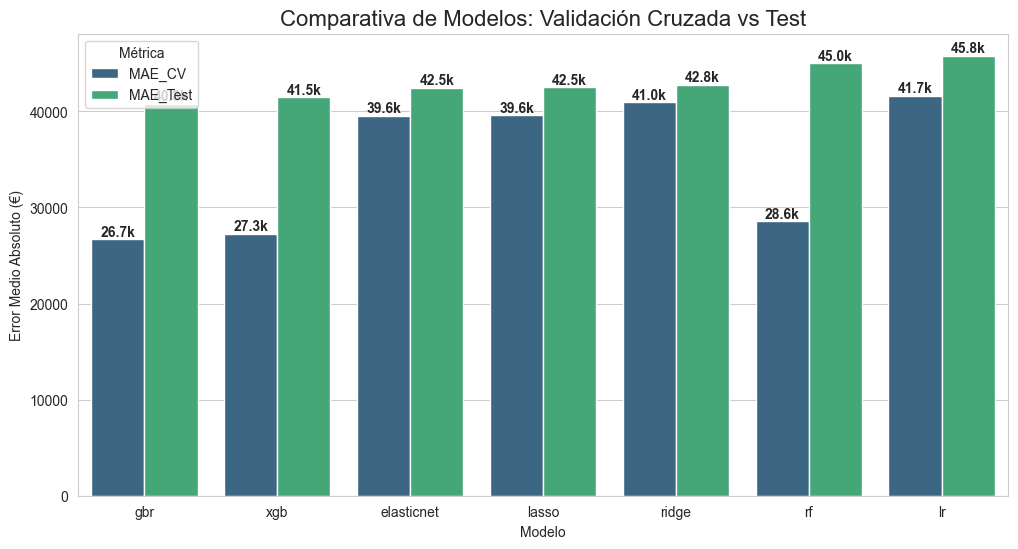

In [30]:
# VISUALIZACIÓN DE RESULTADOS

print("\n" + "="*60)
print("TABLA COMPARATIVA FINAL")
print("="*60)

df_res = pd.DataFrame(resultados_finales).sort_values('MAE_Test')
print(df_res[['Modelo', 'MAE_Test', 'MAE_CV', 'Best_Params']].to_markdown(index=False, floatfmt=",.2f"))

# Gráfico de Barras Comparativo
df_plot = df_res.melt(id_vars='Modelo', value_vars=['MAE_CV', 'MAE_Test'], var_name='Métrica', value_name='MAE (€)')

plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=df_plot, x='Modelo', y='MAE (€)', hue='Métrica', palette='viridis')

# Etiquetas encima de las barras
for p in barplot.patches:
    if p.get_height() > 0:
        barplot.annotate(f'{p.get_height()/1000:,.1f}k', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'bottom', fontsize=10, fontweight='bold')

plt.title('Comparativa de Modelos: Validación Cruzada vs Test', fontsize=16)
plt.ylabel('Error Medio Absoluto (€)')
plt.show()

In [31]:
print(f"\nMejor modelo seleccionado: {best_model_name.upper()} (Guardado como 'mejor_modelo_entrenado_colas.pkl')")
joblib.dump(best_model_pipeline, 'mejor_modelo_entrenado_colas.pkl')
# Guardar columnas para Streamlit
joblib.dump(X_train.columns.tolist(), 'features_columns_colas.pkl')


Mejor modelo seleccionado: GBR (Guardado como 'mejor_modelo_entrenado_colas.pkl')


['features_columns_colas.pkl']

⚙️ Preparando datos para el Analizador SHAP...
✅ Valores SHAP calculados correctamente.

📊 GRÁFICO 1: Ranking de Importancia (Top 15)


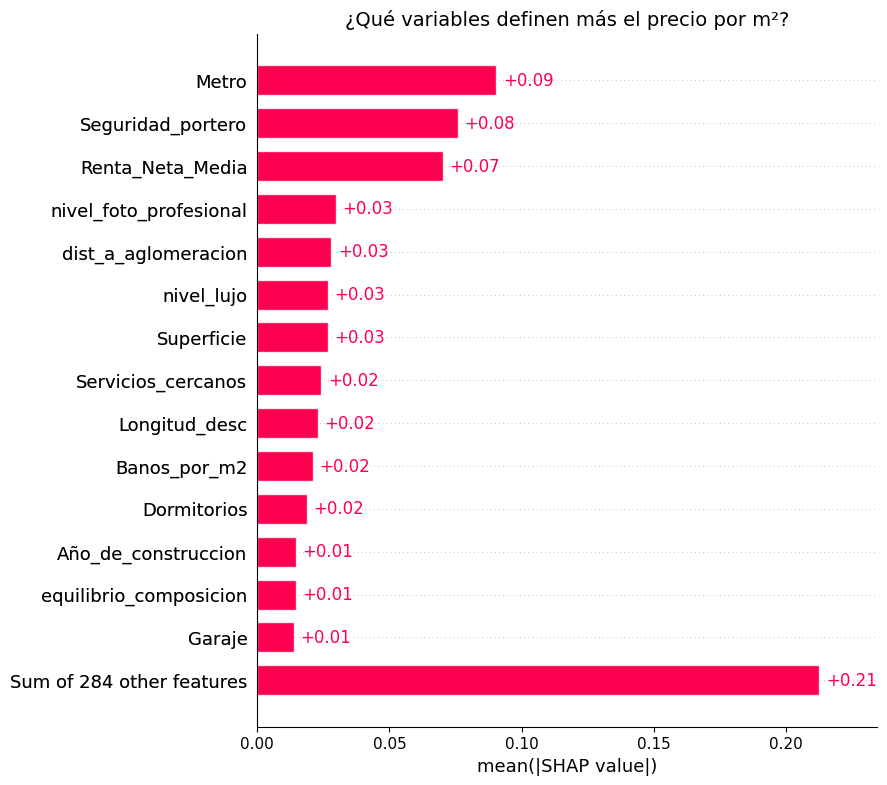


🐝 GRÁFICO 2: Dirección del Impacto (Beeswarm)
INTERPRETACIÓN: Rojo=Alto valor de la variable. Derecha=Sube precio.


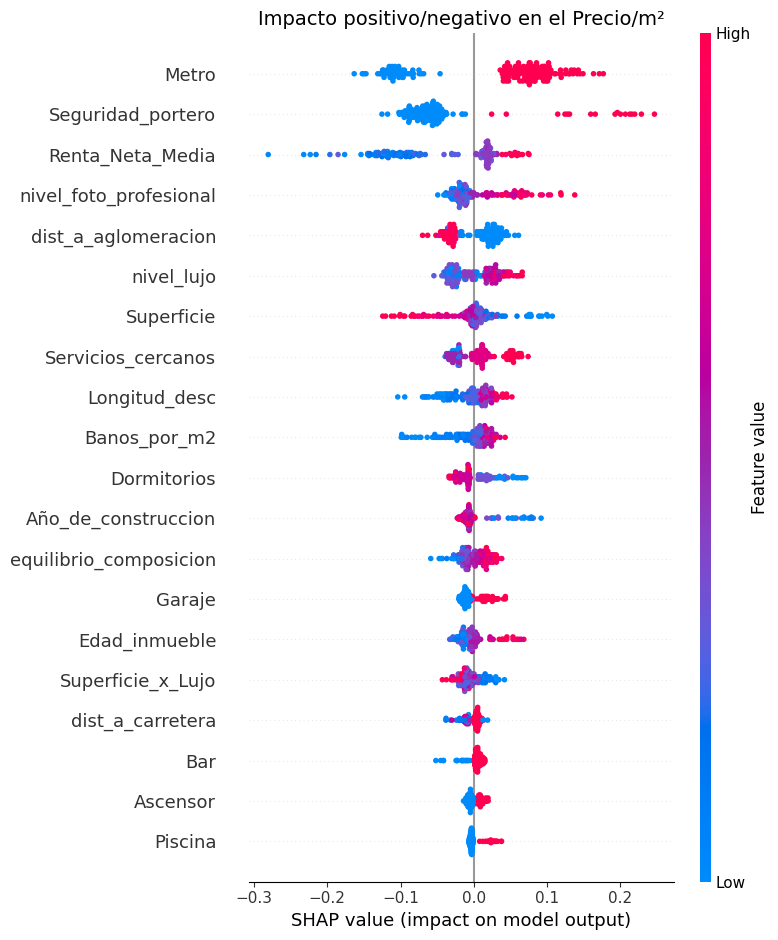


📈 GRÁFICO 3: Análisis Profundo de Variables Clave
Estos gráficos muestran cómo cambia el precio exacto al cambiar una variable.
   -> Analizando: Metro


<Figure size 800x500 with 0 Axes>

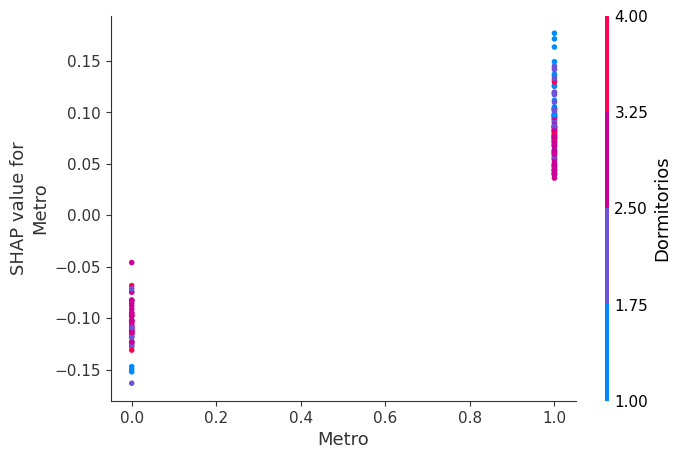

   -> Analizando: Seguridad_portero


<Figure size 800x500 with 0 Axes>

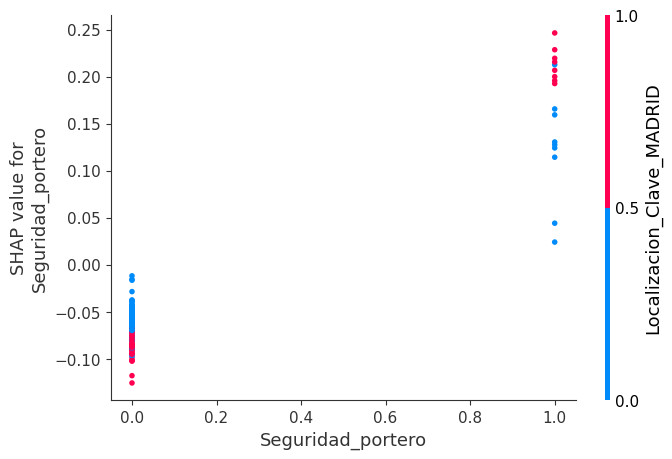

   -> Analizando: Renta_Neta_Media


<Figure size 800x500 with 0 Axes>

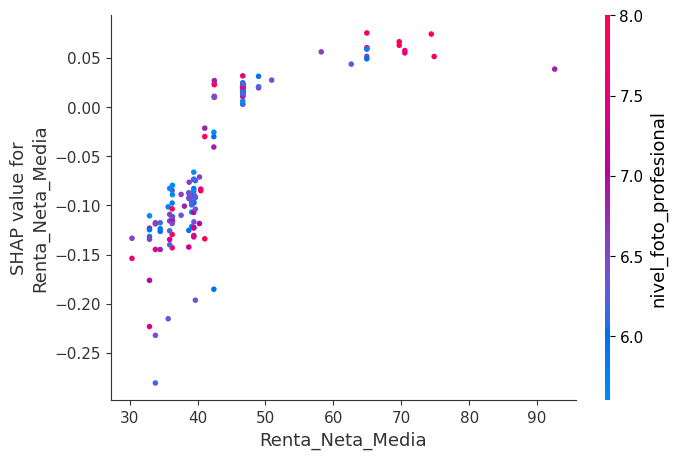

   -> Analizando: Superficie


<Figure size 800x500 with 0 Axes>

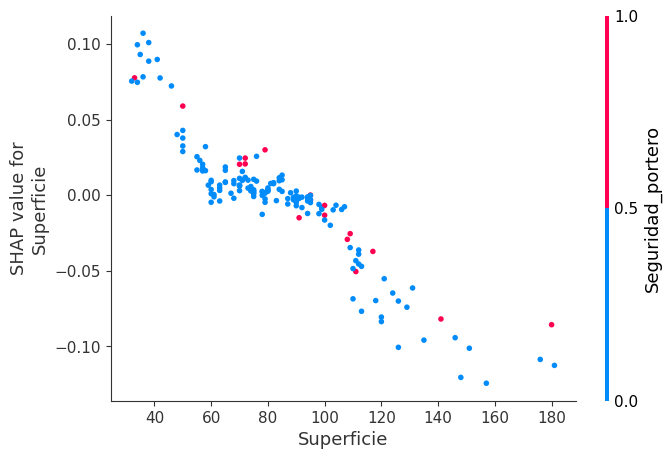


💧 GRÁFICO 4: ¿Por qué ESTA casa vale eso?
Analizando la casa nº 0 del Test Set:
Predicción Precio/m² (Log): 7.78


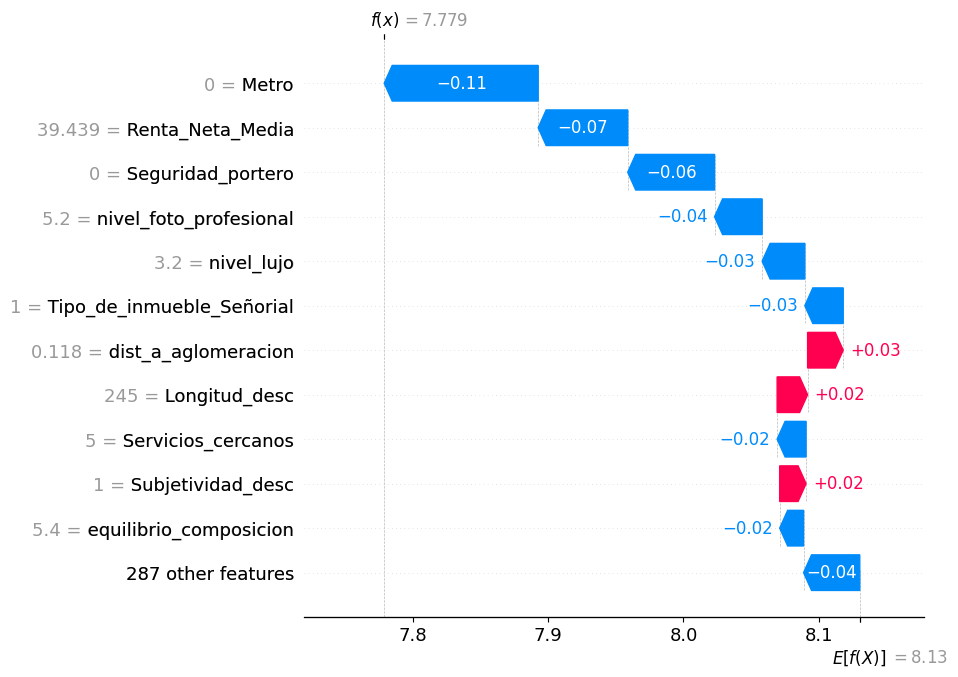


📋 TOP 10 VARIABLES MÁS INFLUYENTES (Resumen)
| col_name               |   feature_importance_vals |
|:-----------------------|--------------------------:|
| Metro                  |                    0.0904 |
| Seguridad_portero      |                    0.0758 |
| Renta_Neta_Media       |                    0.0701 |
| nivel_foto_profesional |                    0.0297 |
| dist_a_aglomeracion    |                    0.0280 |
| nivel_lujo             |                    0.0268 |
| Superficie             |                    0.0267 |
| Servicios_cercanos     |                    0.0243 |
| Longitud_desc          |                    0.0230 |
| Banos_por_m2           |                    0.0209 |


In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

# Aseguramos que el estilo sea limpio
plt.style.use('default') 

# ==============================================================================
# 1. PREPARACIÓN DE DATOS PARA SHAP
# ==============================================================================
print("⚙️ Preparando datos para el Analizador SHAP...")

# Recuperamos el modelo interno y el preprocesador del Pipeline ganador
modelo_interno = best_model_pipeline.named_steps['model']
preprocessor_interno = best_model_pipeline.named_steps['preprocessor']

# Transformamos los datos de test (El modelo necesita números, no categorías crudas)
X_test_transformed = preprocessor_interno.transform(X_test)

# Recuperamos los nombres de las columnas (Crucial para entender los gráficos)
try:
    # Intentamos obtener nombres bonitos del OneHotEncoder
    feature_names = preprocessor_interno.get_feature_names_out()
    # Limpieza: Quitamos prefijos feos como "num__" o "cat__"
    feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]
except:
    # Plan B si falla
    feature_names = [f"Feature_{i}" for i in range(X_test_transformed.shape[1])]

# Creamos un DataFrame de Pandas con los datos transformados y sus nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names)

# Calculamos los valores SHAP (La "magia")
explainer = shap.TreeExplainer(modelo_interno)
shap_values = explainer(X_test_shap)

print("✅ Valores SHAP calculados correctamente.")

# ==============================================================================
# 2. NIVEL MACRO: RANKING DE IMPORTANCIA GLOBAL
# ==============================================================================
print("\n📊 GRÁFICO 1: Ranking de Importancia (Top 15)")
plt.figure(figsize=(10, 6))
plt.title("¿Qué variables definen más el precio por m²?", fontsize=14)
shap.plots.bar(shap_values, max_display=15, show=True)

# ==============================================================================
# 3. NIVEL DE TENDENCIA: SUMMARY PLOT (BEESWARM)
# ==============================================================================
print("\n🐝 GRÁFICO 2: Dirección del Impacto (Beeswarm)")
print("INTERPRETACIÓN: Rojo=Alto valor de la variable. Derecha=Sube precio.")
plt.figure(figsize=(12, 8))
plt.title("Impacto positivo/negativo en el Precio/m²", fontsize=14)
shap.summary_plot(shap_values, X_test_shap, max_display=20, show=True)

# ==============================================================================
# 4. NIVEL MICRO: CURVAS DE DEPENDENCIA (DEPENDENCE PLOTS)
# ==============================================================================
print("\n📈 GRÁFICO 3: Análisis Profundo de Variables Clave")
print("Estos gráficos muestran cómo cambia el precio exacto al cambiar una variable.")

# Buscamos variables interesantes automáticamente
top_features = X_test_shap.columns[np.argsort(np.abs(shap_values.values).mean(0))][::-1]

# Vamos a graficar las 3 más importantes y 'Superficie' si no está en el top
vars_to_plot = list(top_features[:3])
if 'Superficie' in X_test_shap.columns and 'Superficie' not in vars_to_plot:
    vars_to_plot.append('Superficie')

for var in vars_to_plot:
    if var in X_test_shap.columns:
        print(f"   -> Analizando: {var}")
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(var, shap_values.values, X_test_shap, show=True)

# ==============================================================================
# 5. NIVEL CASO: AUDITORÍA INDIVIDUAL (WATERFALL)
# ==============================================================================
print("\n💧 GRÁFICO 4: ¿Por qué ESTA casa vale eso?")
# Elegimos una casa aleatoria (o la primera del test set)
indice_casa = 0 

print(f"Analizando la casa nº {indice_casa} del Test Set:")
print(f"Predicción Precio/m² (Log): {modelo_interno.predict(X_test_transformed[indice_casa:indice_casa+1])[0]:.2f}")

plt.figure(figsize=(8, 8))
shap.plots.waterfall(shap_values[indice_casa], max_display=12, show=True)

# ==============================================================================
# 6. RESUMEN DE TEXTO PARA COPIAR
# ==============================================================================
# Extraemos el top 10 numéricamente para que me lo pases
vals = np.abs(shap_values.values).mean(0)
feature_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['col_name','feature_importance_vals'])
feature_importance.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)

print("\n" + "="*40)
print("📋 TOP 10 VARIABLES MÁS INFLUYENTES (Resumen)")
print("="*40)
print(feature_importance.head(10).to_markdown(index=False, floatfmt=".4f"))